# Importing Lib's & Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
# For Text Preprocessing.
import re
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from nltk.tokenize import word_tokenize
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
# For RNN
from sklearn.model_selection import train_test_split
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout

In [ ]:
!unzip '/content/IMDB Dataset.csv.zip'

In [3]:
df = pd.read_csv('/content/IMDB Dataset.csv')
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


# Data Preprocessing

In [4]:
df.shape

(50000, 2)

In [5]:
df.isnull().sum()

,0
review,0
sentiment,0


In [6]:
df.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [7]:
print(df.duplicated().sum())

418


In [8]:
print(df.drop_duplicates(inplace=True))

None


In [9]:
df.shape

(49582, 2)

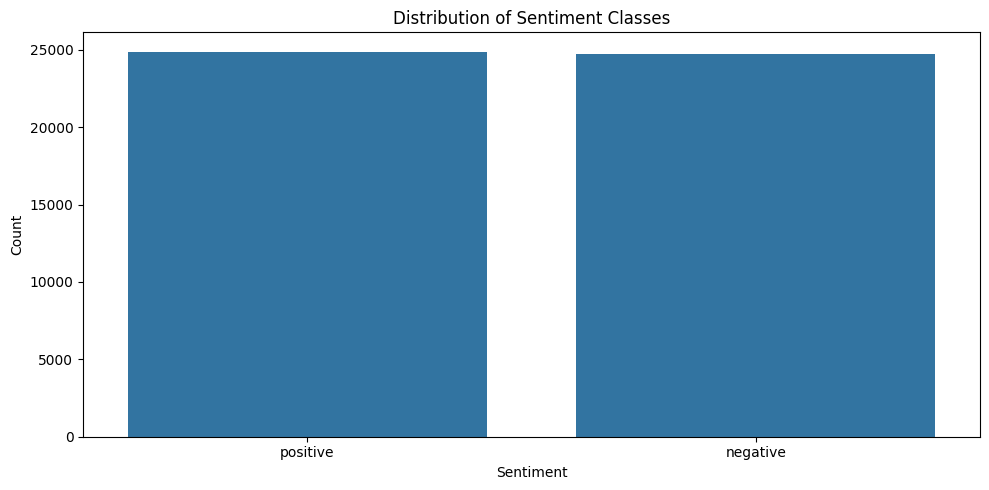

In [35]:
plt.figure(figsize= (10, 5))
sns.barplot(x= df['sentiment'].value_counts().index, y= df['sentiment'].value_counts())
plt.title('Distribution of Sentiment Classes')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Text Preprocessing

In [11]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [12]:
def clean_text(text):
    # Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)
    # Remove non-alphanumeric characters except for spaces
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    # Remove numbers/digits.
    text = re.sub(r'\d+', '', text)
    # Convert to lowercase
    text = text.lower()
    # Remove stop words
    stop_words = set(stopwords.words('english'))
    text = ' '.join([word for word in text.split() if word not in stop_words])
    # Remove extra whitespace
    text = ' '.join(text.split())
    return text

df['clean_text'] = df['review'].apply(clean_text)
display(df.head())

,review,sentiment,clean_text
0,One of the other reviewers has mentioned that ...,positive,one reviewers mentioned watching oz episode yo...
1,A wonderful little production. <br /><br />The...,positive,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,negative,basically theres family little boy jake thinks...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love time money visually stunni...


# Encoding Data

In [13]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Encoded_Sentiment'] = le.fit_transform(df['sentiment'])
df.sample(5)

,review,sentiment,clean_text,Encoded_Sentiment
49158,"Wow baby, this is indeed some fine Asian horro...",positive,wow baby indeed fine asian horrorgore crazy ou...,1
12429,There were only two things that kept me intere...,negative,two things kept interested film waiting owen w...,0
3154,"A noble effort, I guess, but ultimately a poor...",negative,noble effort guess ultimately poor one seeing ...,0
6167,It is a superb Swedish film .. it was the firs...,positive,superb swedish film first swedish film ive see...,1
14794,In what seemed like the longest 1hour 35 I've ...,negative,seemed like longest hour ive endure long time ...,0


# Tokenizing & Padding

In [14]:
token = Tokenizer()
token.fit_on_texts(df['clean_text'])
seqs = token.texts_to_sequences(df['clean_text'])

In [15]:
print('The word index of Tokenizer is: \n',token.word_index)

Output hidden; open in https://colab.research.google.com to view.

In [16]:
seq_len = max([len(seq) for seq in seqs])
seq_len

1428

In [17]:
padded_seq = pad_sequences(seqs, maxlen=seq_len, padding='post')

# Simple RNN Model

In [18]:
from tensorflow.keras.layers import Embedding, SimpleRNN

rnn_model = Sequential([
    Embedding(input_dim= len(token.word_index) + 1, output_dim= 64), # creates dense vector of words.
    SimpleRNN(128, activation= 'tanh', return_sequences= True),
    Dropout(0.2),
    SimpleRNN(64, activation= 'tanh'), # In SimpleRNN 'tanh' is prefered.
    Dropout(0.2),
    Dense(1, activation= 'sigmoid')
])

rnn_model.compile(optimizer= Adam(learning_rate= 0.001), loss= 'binary_crossentropy', metrics= ['accuracy'])

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(padded_seq, df['Encoded_Sentiment'], test_size=0.2, random_state=42)

history = rnn_model.fit(X_train, y_train, epochs= 5, batch_size=32, validation_data=(X_val, y_val))

Epoch 1/5
1240/1240 ━━━━━━━━━━━━━━━━━━━━ 275s 222ms/step - accuracy: 0.4957 - loss: 0.7049 - val_accuracy: 0.5101 - val_loss: 0.6965
Epoch 2/5
1240/1240 ━━━━━━━━━━━━━━━━━━━━ 311s 213ms/step - accuracy: 0.5066 - loss: 0.6957 - val_accuracy: 0.5020 - val_loss: 0.6939
Epoch 3/5
1240/1240 ━━━━━━━━━━━━━━━━━━━━ 313s 206ms/step - accuracy: 0.5003 - loss: 0.6944 - val_accuracy: 0.5102 - val_loss: 0.6926
Epoch 4/5
1240/1240 ━━━━━━━━━━━━━━━━━━━━ 266s 210ms/step - accuracy: 0.5104 - loss: 0.6937 - val_accuracy: 0.5101 - val_loss: 0.6953
Epoch 5/5
1240/1240 ━━━━━━━━━━━━━━━━━━━━ 262s 210ms/step - accuracy: 0.5032 - loss: 0.6944 - val_accuracy: 0.5108 - val_loss: 0.6926


# Model Evaluation

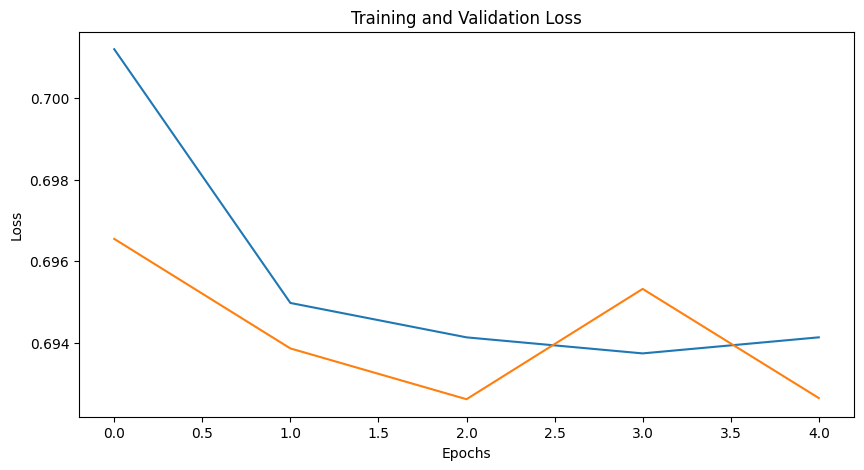

In [22]:
plt.figure(figsize= (10, 5))
plt.plot(history.history['loss'], label= 'Training Loss')
plt.plot(history.history['val_loss'], label= 'Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

In [23]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = (rnn_model.predict(padded_seq) > 0.5).astype('int32')
cm = confusion_matrix(df['Encoded_Sentiment'], y_pred)
cr = classification_report(df['Encoded_Sentiment'], y_pred)
print('Confusion Matrix: \n', cm)
print('Classification Report: \n', cr)

1550/1550 ━━━━━━━━━━━━━━━━━━━━ 80s 51ms/step
Confusion Matrix: 
 [[21546  3152]
 [21123  3761]]
Classification Report: 
               precision    recall  f1-score   support

           0       0.50      0.87      0.64     24698
           1       0.54      0.15      0.24     24884

    accuracy                           0.51     49582
   macro avg       0.52      0.51      0.44     49582
weighted avg       0.52      0.51      0.44     49582



# Saving Model

In [30]:
from tensorflow.keras.models import load_model
rnn_model.save('Sentiment_Model_RNN.h5')

loaded_model = load_model('Sentiment_Model_RNN.h5')

# Sentiment Predictions

In [31]:
def predict_sentiment(sentence):
    sentence = clean_text(sentence)
    sequence = token.texts_to_sequences([sentence])
    padded_sequence = pad_sequences(sequence, maxlen=seq_len, padding='post')

    prediction = loaded_model.predict(padded_sequence)[0][0]
    if prediction >= 0.5:
        return 'Positive'
    else:
        return 'Negative'

In [32]:
# Test1
test_sent = 'I hate this movie and its awful'
print(f'Sentiment: {predict_sentiment(test_sent)}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 612ms/step
Sentiment: Negative


In [33]:
# Test2
test_sent2 = 'I would like to see this film again!'
print(f'Sentiment: {predict_sentiment(test_sent2)}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
Sentiment: Positive
